In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt

In [2]:
comparisonDF = pd.read_csv("/Users/loftum/Desktop/PersonalProjects/yq12Estimator/fatherSon_Yq12.csv").drop(columns=['Unnamed: 0'])

In [3]:
ratioDF=pd.read_csv("/Users/loftum/Desktop/PersonalProjects/yq12Estimator/fatherSon_RatioDF_Yq12.csv").drop(columns=['Unnamed: 0'])

In [4]:
ratioDF

,Son,Father,Color
0,0.935382,0.824557,FatherLarger
1,1.011027,0.922376,FatherLarger
2,0.939524,0.854772,FatherLarger
3,0.992936,0.916575,SonLarger
4,0.926966,0.908097,FatherLarger
...,...,...,...
298,0.931591,0.926769,FatherLarger
299,0.981406,0.867568,SonLarger
300,1.091105,1.027070,FatherLarger
301,0.867413,0.947865,FatherLarger


In [5]:
ratioDF['Difference'] = [abs(x-y) for x,y in zip(ratioDF['Father'], ratioDF['Son'])]

(array([92., 71., 67., 38., 19.,  7.,  3.,  3.,  1.,  2.]),
 array([0.00047603, 0.03101372, 0.06155142, 0.09208911, 0.12262681,
        0.1531645 , 0.1837022 , 0.21423989, 0.24477759, 0.27531528,
        0.30585298]),
 <BarContainer object of 10 artists>)

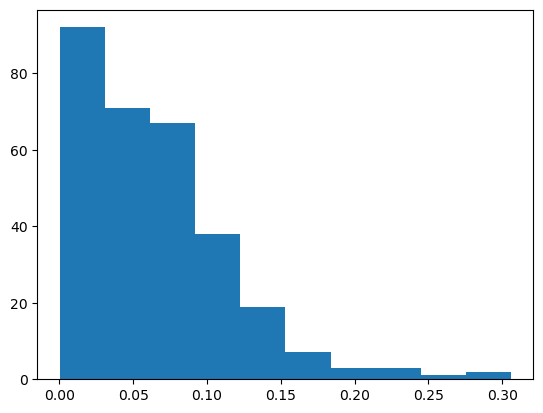

In [6]:
plt.hist(ratioDF['Difference'])

In [7]:
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon, binomtest, t
np.set_printoptions(suppress=True)

# Expect df with columns: father_ratio, son_ratio, optional family_id
df = ratioDF.dropna(subset=["Father","Son"]).copy()
df = df[(df["Father"]>0) & (df["Son"]>0)].copy()

# Log scale (1 -> 0)
df["df_log"] = np.log(df["Father"])
df["ds_log"] = np.log(df["Son"])

# Distance shrinkage toward 0
df["Delta"] = df["ds_log"].abs() - df["df_log"].abs()   # negative => son closer to 1

n = len(df)
n_closer = int((df["Delta"] < 0).sum())
p_closer = n_closer / n

# Exact binomial 95% CI for proportion closer
from statsmodels.stats.proportion import proportion_confint
ci_lo, ci_hi = proportion_confint(n_closer, nobs=n, alpha=0.05, method="beta")

# Sign test: H1 proportion closer > 0.5
p_sign = binomtest(n_closer, n=n, p=0.5, alternative="greater").pvalue

# Wilcoxon signed-rank on Delta (one-sided: median(Delta) < 0)
try:
    w_stat, p_wil = wilcoxon(df["Delta"], alternative="less", zero_method="wilcox")
except TypeError:
    # Older SciPy: two-sided then halve if negative direction
    w_stat, p2 = wilcoxon(df["Delta"])
    p_wil = p2/2 if df["Delta"].median() < 0 else 1 - p2/2

# Effect sizes for Delta
median_Delta = float(df["Delta"].median())
iqr_Delta = float(df["Delta"].quantile(0.75) - df["Delta"].quantile(0.25))

# Slope (shrinkage) through origin: ds_log = rho * df_log + error
x = df["df_log"].values
y = df["ds_log"].values
Sxx = np.sum(x*x)
Sxy = float(np.sum(x*y))
rho_hat = Sxy / Sxx

# Std. error of slope (through origin)
resid = y - rho_hat * x
df_dof = max(n - 1, 1)
sigma2 = np.sum(resid**2) / df_dof
se_rho = float(np.sqrt(sigma2 / Sxx))

# One-sided test H0: rho >= 1 vs H1: rho < 1
t_stat = (rho_hat - 1.0) / se_rho
p_rho = float(t.cdf(t_stat, df=df_dof))  # one-sided lower tail

# R^2 (through origin)
R2_origin = 1.0 - (np.sum(resid**2) / np.sum(y**2))

# Sign concordance (same side of 1)
sign_match = int(np.sum(np.sign(x) == np.sign(y)))
p_sign_conc = sign_match / n

# --------- PRINTS ----------
print("=== Father–Son Shrinkage Toward 1 (log scale) ===")
print(f"Pairs analyzed: {n}")
print()

print("Proportion of sons closer to 1 than fathers")
print(f"  p_closer = {p_closer:.3f}  (n_closer = {n_closer}/{n})")
print(f"  95% CI (Clopper–Pearson): [{ci_lo:.3f}, {ci_hi:.3f}]")
print(f"  Sign test (H1: p>0.5): p = {p_sign:.3g}")
print()

print("Distance shift (Delta = |log(son)| - |log(father)|)")
print(f"  Median Delta = {median_Delta:.4f}  (IQR = {iqr_Delta:.4f})")
print(f"  Wilcoxon signed-rank (H1: median<0): W = {w_stat}, p = {p_wil:.3g}")
print()

print("Shrinkage slope (through origin):  log(son) = rho * log(father)")
print(f"  rhô = {rho_hat:.3f}  (SE = {se_rho:.3f}, t = {t_stat:.2f}, df = {df_dof})")
print(f"  One-sided test H0: rho>=1 vs H1: rho<1  →  p = {p_rho:.3g}")
print(f"  R^2 (origin) = {R2_origin:.3f}")
print()

print("Direction agreement (above/below 1)")
print(f"  sign match = {sign_match}/{n}  ({p_sign_conc:.3f})")


=== Father–Son Shrinkage Toward 1 (log scale) ===
Pairs analyzed: 303

Proportion of sons closer to 1 than fathers
  p_closer = 0.614  (n_closer = 186/303)
  95% CI (Clopper–Pearson): [0.556, 0.669]
  Sign test (H1: p>0.5): p = 4.39e-05

Distance shift (Delta = |log(son)| - |log(father)|)
  Median Delta = -0.0173  (IQR = 0.0978)
  Wilcoxon signed-rank (H1: median<0): W = 18534.0, p = 0.00162

Shrinkage slope (through origin):  log(son) = rho * log(father)
  rhô = 0.813  (SE = 0.028, t = -6.79, df = 302)
  One-sided test H0: rho>=1 vs H1: rho<1  →  p = 2.91e-11
  R^2 (origin) = 0.742

Direction agreement (above/below 1)
  sign match = 253/303  (0.835)


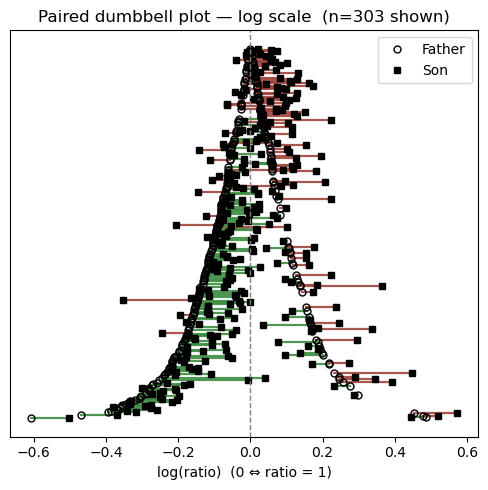

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_paired_dumbbell(df, father_col="Father", son_col="Son",
                         mode="log", max_pairs=303, title=None):
    """
    mode = "log"  -> plot log(ratio) (0 means ratio=1, left<1, right>1)
         = "abs"  -> plot absolute distance to 1: |log(ratio)|
    max_pairs: cap the number of rows to avoid overcrowding.
    """
    d = df[[father_col, son_col]].dropna().copy()
    # keep positive ratios
    d = d[(d[father_col] > 0) & (d[son_col] > 0)].copy()
    d["df_log"] = np.log(d[father_col].astype(float))
    d["ds_log"] = np.log(d[son_col].astype(float))

    if mode == "log":
        x_f = d["df_log"].values
        x_s = d["ds_log"].values
        x_label = "log(ratio)  (0 ⇔ ratio = 1)"
        x_ref = 0.0
    elif mode == "abs":
        x_f = np.abs(d["df_log"].values)
        x_s = np.abs(d["ds_log"].values)
        x_label = "|log(ratio)|  (distance from 1)"
        x_ref = 0.0
    else:
        raise ValueError("mode must be 'log' or 'abs'")

    # order by father's magnitude so the plot is tidy
    order_idx = np.argsort(-np.abs(d["df_log"].values))
    x_f = x_f[order_idx]
    x_s = x_s[order_idx]

    n = len(x_f)
    if n == 0:
        raise ValueError("No valid pairs to plot.")
    if n > max_pairs:
        x_f = x_f[:max_pairs]
        x_s = x_s[:max_pairs]
        n = max_pairs

    # whether son is closer (for coloring the segment)
    closer = np.abs(x_s if mode=="log" else x_s) < np.abs(x_f if mode=="log" else x_f)

    # figure size: ~0.18 in per row, capped
    height = min(0.18 * n + 1.0, 16)
    plt.figure(figsize=(5, 5))

    y = np.arange(n)

    # segments
    for i in range(n):
        c = "#3C8D40" if closer[i] else "#A0443B"  # green if closer, brick if not
        plt.plot([x_f[i], x_s[i]], [y[i], y[i]], '-', lw=1.6, color=c, alpha=0.9)

    # endpoints: father (open circle), son (filled square)
    plt.plot(x_f, y, 'o', mfc='none', mec='black', ms=5, label="Father")
    plt.plot(x_s, y, 's', mfc='black', mec='black', ms=4, label="Son")

    # reference line at 0 (1 on raw scale)
    plt.axvline(x_ref, lw=1, ls='--', color='grey')

    plt.yticks([])  # hide crowded y labels
    plt.xlabel(x_label)
    ttl = title or (f"Paired dumbbell plot — {mode} scale  (n={n} shown)")
    plt.title(ttl)
    plt.legend(loc="upper right")
    
    plt.tight_layout()
    plt.savefig("/Users/loftum/Desktop/PersonalProjects/yq12Estimator/Figures/FathervsSonLinePlot_dumbbell.Jan112026.jpeg", format='jpeg', dpi=300, bbox_inches='tight')
    plt.savefig("/Users/loftum/Desktop/PersonalProjects/yq12Estimator/Figures/FathervsSonLinePlot_dumbbell.Jan112026.pdf", format='pdf', bbox_inches='tight')

    plt.show()

plot_paired_dumbbell(df, father_col="Father", son_col="Son", mode="log")

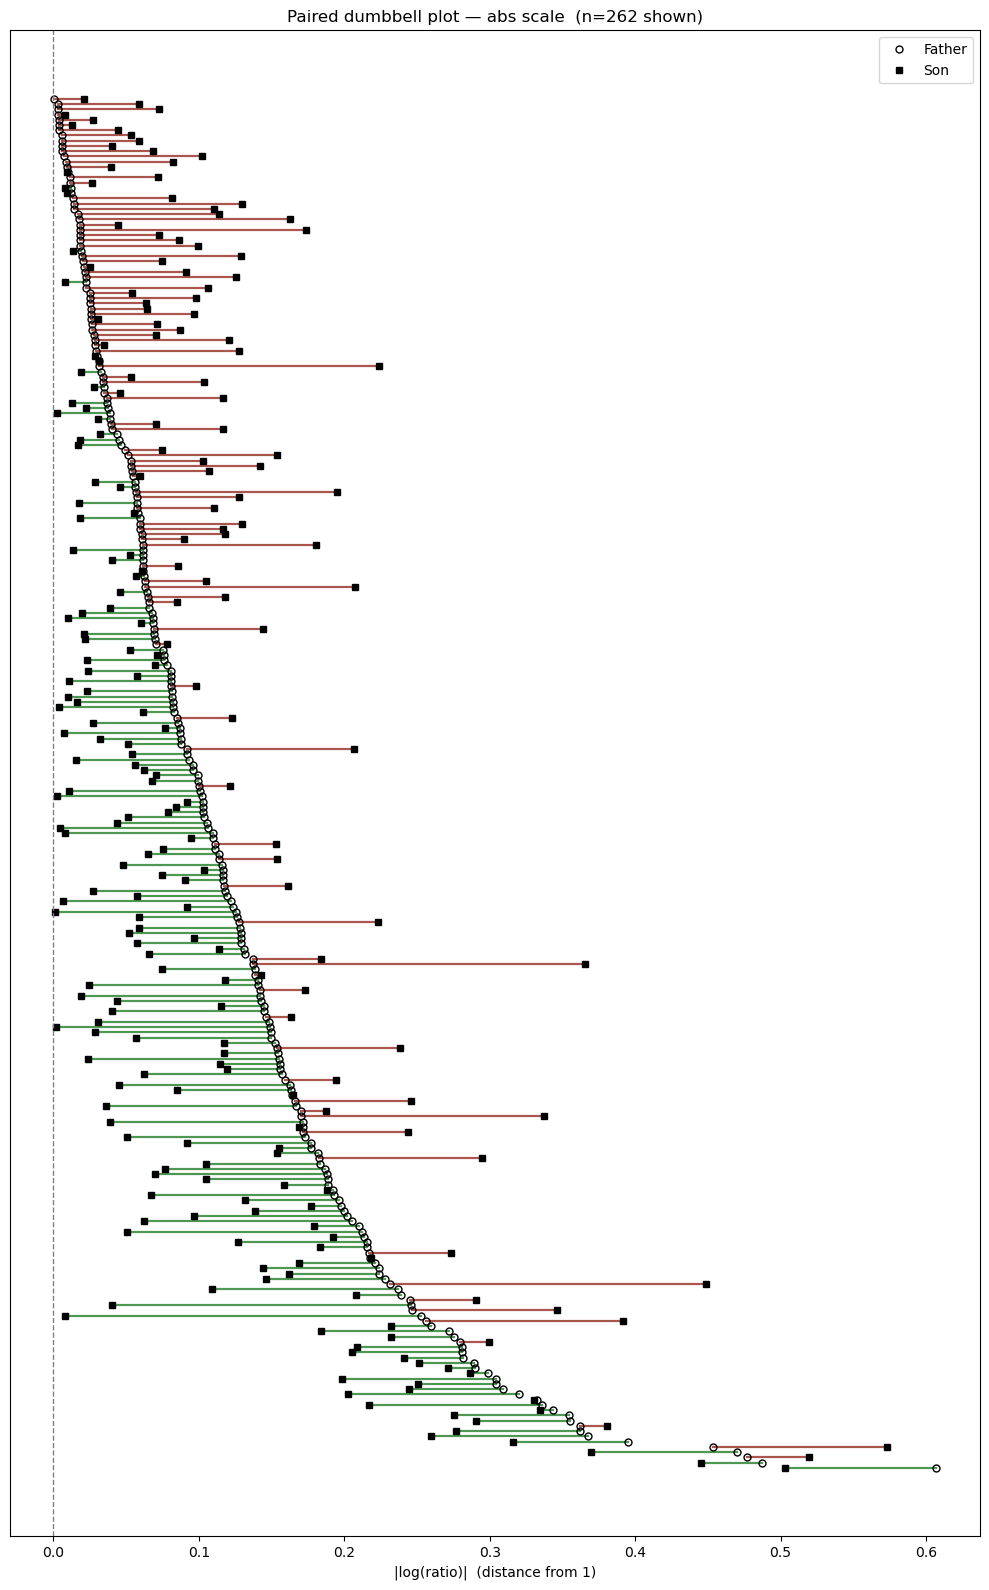

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_paired_dumbbell(df, father_col="Father", son_col="Son",
                         mode="log", max_pairs=300, title=None):
    """
    mode = "log"  -> plot log(ratio) (0 means ratio=1, left<1, right>1)
         = "abs"  -> plot absolute distance to 1: |log(ratio)|
    max_pairs: cap the number of rows to avoid overcrowding.
    """
    d = df[[father_col, son_col]].dropna().copy()
    # keep positive ratios
    d = d[(d[father_col] > 0) & (d[son_col] > 0)].copy()
    d["df_log"] = np.log(d[father_col].astype(float))
    d["ds_log"] = np.log(d[son_col].astype(float))

    if mode == "log":
        x_f = d["df_log"].values
        x_s = d["ds_log"].values
        x_label = "log(ratio)  (0 ⇔ ratio = 1)"
        x_ref = 0.0
    elif mode == "abs":
        x_f = np.abs(d["df_log"].values)
        x_s = np.abs(d["ds_log"].values)
        x_label = "|log(ratio)|  (distance from 1)"
        x_ref = 0.0
    else:
        raise ValueError("mode must be 'log' or 'abs'")

    # order by father's magnitude so the plot is tidy
    order_idx = np.argsort(-np.abs(d["df_log"].values))
    x_f = x_f[order_idx]
    x_s = x_s[order_idx]

    n = len(x_f)
    if n == 0:
        raise ValueError("No valid pairs to plot.")
    if n > max_pairs:
        x_f = x_f[:max_pairs]
        x_s = x_s[:max_pairs]
        n = max_pairs

    # whether son is closer (for coloring the segment)
    closer = np.abs(x_s if mode=="log" else x_s) < np.abs(x_f if mode=="log" else x_f)

    # figure size: ~0.18 in per row, capped
    height = min(0.18 * n + 1.0, 16)
    plt.figure(figsize=(10, height))

    y = np.arange(n)

    # segments
    for i in range(n):
        c = "#3C8D40" if closer[i] else "#A0443B"  # green if closer, brick if not
        plt.plot([x_f[i], x_s[i]], [y[i], y[i]], '-', lw=1.6, color=c, alpha=0.9)

    # endpoints: father (open circle), son (filled square)
    plt.plot(x_f, y, 'o', mfc='none', mec='black', ms=5, label="Father")
    plt.plot(x_s, y, 's', mfc='black', mec='black', ms=4, label="Son")

    # reference line at 0 (1 on raw scale)
    plt.axvline(x_ref, lw=1, ls='--', color='grey')

    plt.yticks([])  # hide crowded y labels
    plt.xlabel(x_label)
    ttl = title or (f"Paired dumbbell plot — {mode} scale  (n={n} shown)")
    plt.title(ttl)
    plt.legend(loc="upper right")
    plt.tight_layout()
    #plt.savefig("/Users/loftum/Desktop/PersonalProjects/yq12Estimator/Figures/FathervsSonLinePlot_dumbbell_absolute.jpeg", format='jpeg', dpi=300, bbox_inches='tight')
    #plt.savefig("/Users/loftum/Desktop/PersonalProjects/yq12Estimator/Figures/FathervsSonLinePlot_dumbbell_absolute.pdf", format='pdf', dpi=300, bbox_inches='tight')

    plt.show()

# Example usage:
#plot_paired_dumbbell(df, father_col="Father", son_col="Son", mode="log")
plot_paired_dumbbell(df, father_col="Father", son_col="Son", mode="abs")

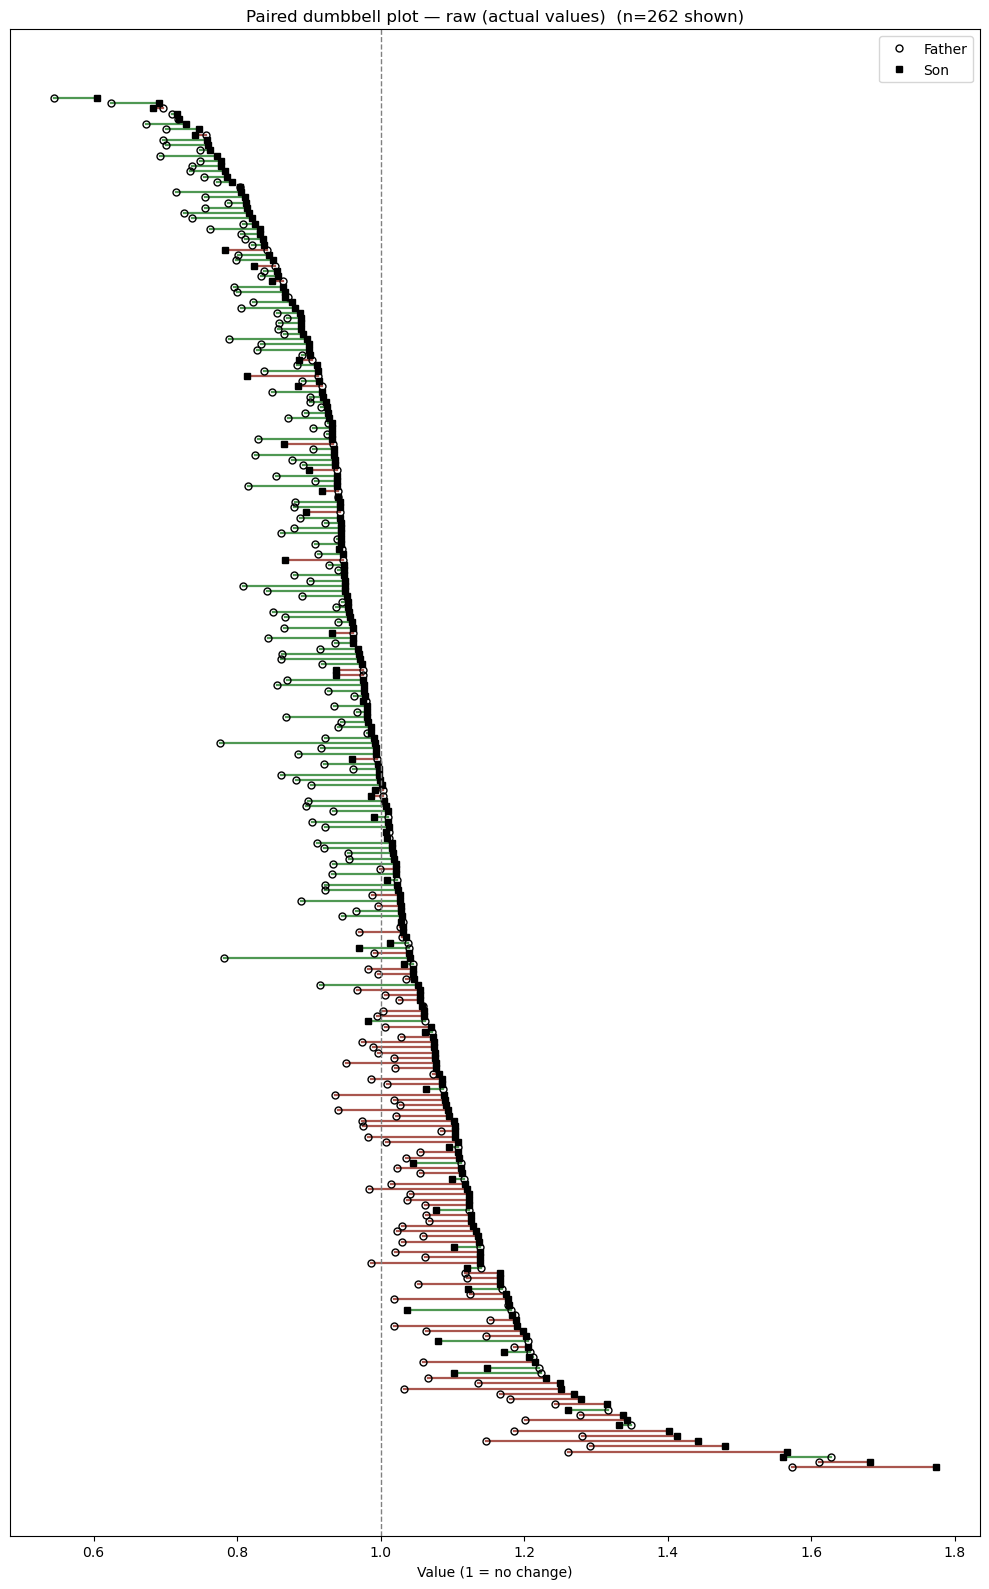

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_paired_dumbbell(df, father_col="Father", son_col="Son",
                         mode="raw", max_pairs=300, title=None):
    """
    Plot paired 'dumbbell' comparisons for Father vs Son values.

    Parameters
    ----------
    df : pandas.DataFrame
        Must contain columns `father_col` and `son_col`.
    father_col, son_col : str
        Column names for father and son values.
    mode : {"raw", "log", "abs"}
        - "raw": plot actual values (reference at x=1; 'closer' means closer to 1).
        - "log": plot log(values) (reference at x=0; 'closer' means smaller |log(value)|).
        - "abs": plot |log(values)| distances from 1 (reference at x=0; 'closer' means smaller distance).
    max_pairs : int
        Maximum number of pairs to draw (top rows by ordering rule).
    title : str or None
        Optional plot title.
    """
    # Prepare data
    d = df[[father_col, son_col]].dropna().copy()
    # Keep positive rows (needed for log/abs modes; reasonable for ratios in raw mode too)
    d = d[(d[father_col] > 0) & (d[son_col] > 0)].copy()

    f = d[father_col].astype(float).values
    s = d[son_col].astype(float).values

    # Build plotting coordinates and 'closer' flags
    if mode == "raw":
        x_f, x_s = f, s
        x_label = "Value (1 = no change)"
        x_ref = 1.0
        # Closer to 1 on the raw scale
        closer = np.abs(x_s - 1.0) < np.abs(x_f - 1.0)
        # Order: largest magnitude to front (you can switch to np.argsort(-x_f) if you prefer by-father)
        order_idx = np.argsort(-np.maximum(x_f, x_s))

    elif mode == "log":
        lf, ls = np.log(f), np.log(s)
        x_f, x_s = lf, ls
        x_label = "log(value)  (0 ⇔ value = 1)"
        x_ref = 0.0
        closer = np.abs(x_s) < np.abs(x_f)
        # Order by father's |log| magnitude for tidy stacking
        order_idx = np.argsort(-np.abs(x_f))

    elif mode == "abs":
        lf, ls = np.log(f), np.log(s)
        x_f, x_s = np.abs(lf), np.abs(ls)
        x_label = "|log(value)|  (distance from 1)"
        x_ref = 0.0
        closer = x_s < x_f
        # Order by father's distance
        order_idx = np.argsort(-x_f)

    else:
        raise ValueError("mode must be 'raw', 'log', or 'abs'")

    # Apply ordering consistently to all arrays
    x_f = x_f[order_idx]
    x_s = x_s[order_idx]
    closer = closer[order_idx]

    # Limit to max_pairs consistently
    n = len(x_f)
    if n == 0:
        raise ValueError("No valid pairs to plot.")
    if n > max_pairs:
        x_f = x_f[:max_pairs]
        x_s = x_s[:max_pairs]
        closer = closer[:max_pairs]
        n = max_pairs

    # Figure layout
    height = min(0.18 * n + 1.0, 16)
    plt.figure(figsize=(10, height))
    y = np.arange(n)

    # Line segments (green if son is closer by the chosen rule, brick otherwise)
    for i in range(n):
        c = "#3C8D40" if closer[i] else "#A0443B"
        plt.plot([x_f[i], x_s[i]], [y[i], y[i]], '-', lw=1.6, color=c, alpha=0.9)

    # Endpoints: father (open circle), son (filled square)
    plt.plot(x_f, y, 'o', mfc='none', mec='black', ms=5, label="Father")
    plt.plot(x_s, y, 's', mfc='black', mec='black', ms=4, label="Son")

    # Reference line: 1 for raw; 0 for log/abs
    plt.axvline(x_ref, lw=1, ls='--', color='grey')

    plt.yticks([])  # hide crowded y labels
    labels = {"raw": "raw (actual values)", "log": "log scale", "abs": "|log| distance"}
    plt.xlabel(x_label)
    plt.title(title or f"Paired dumbbell plot — {labels[mode]}  (n={n} shown)")
    plt.legend(loc="upper right")
    plt.tight_layout()
    #plt.savefig("/Users/loftum/Desktop/PersonalProjects/yq12Estimator/Figures/FathervsSonLinePlot_dumbbell_absolute.jpeg", format='jpeg', dpi=300, bbox_inches='tight')
    #plt.savefig("/Users/loftum/Desktop/PersonalProjects/yq12Estimator/Figures/FathervsSonLinePlot_dumbbell_absolute.pdf", format='pdf', dpi=300, bbox_inches='tight')

    plt.show()
plot_paired_dumbbell(df, father_col="Father", son_col="Son", mode="raw")
